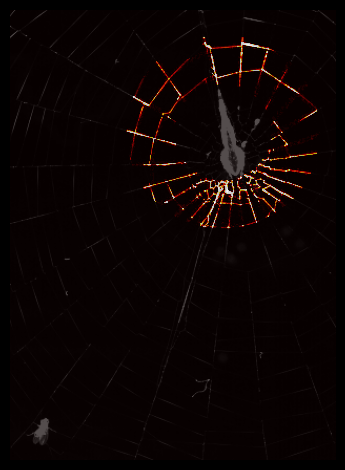

In [1]:

import numpy as np
import matplotlib
import matplotlib.animation as manimation
import os, glob, numpy as np, matplotlib.pyplot as plt, scipy
import imageio
from moviepy.editor import VideoFileClip

## Specify ffmpeg on HsinYi's macbook pro
# plt.rcParams['animation.ffmpeg_path'] = '/Users/hsinyihung/opt/anaconda3/bin/ffmpeg'
##


fname ='Z:\HsinYi\web_vibration/082923/082923_spider_prey_C001H001S0001/082923_spider_prey_C001H001S0001.avi'
signal_map = np.load(fname.replace('.avi','_signal_map.npz'))
signal_map = signal_map['signal_map']
signal_data = np.load(fname.replace('.avi','_signal_map_radii_data.npz'))
signal_data = signal_data['arr_0']
data2 = np.load(fname.replace(".avi", ".xyt") + '.npy')



x1 = 414
x2 = 843
y1 = 260
y2 = 570
plt.style.use('dark_background')
fig = plt.figure()
ax2 = plt.subplot()
z=0

im = ax2.imshow(data2[x1:x2, y1:y2, z], cmap='gray')
lm = ax2.imshow(signal_map[x1:x2, y1:y2, z], cmap='hot', vmin=0, vmax=30, alpha=0.7)
ax2.axis('off')

# lm = ax2.imshow(data[:, :, 0], cmap='gray', alpha =0.2)

plt.tight_layout()
plt.show()

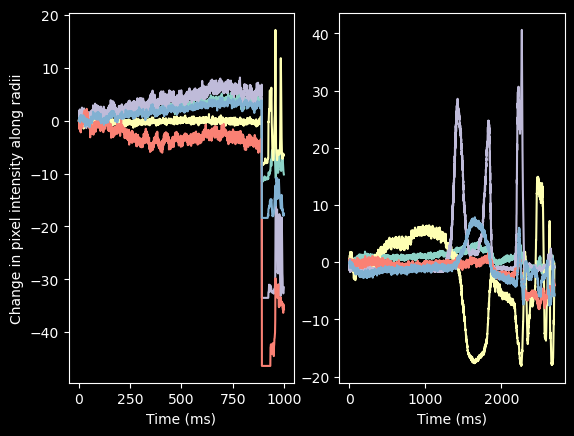

In [13]:
plt.style.use('dark_background')
ax3 = plt.subplot(121)
ax3.plot(signal_data[0,0:1000]-signal_data[0,0], label ='Radii 0')
ax3.plot(signal_data[1,0:1000]-signal_data[1,0], label ='Radii 1')
ax3.plot(signal_data[4,0:1000]-signal_data[4,0], label ='Radii 4')
ax3.plot(signal_data[15,0:1000]-signal_data[15,0], label ='Radii 15')
ax3.plot(signal_data[2,0:1000]-signal_data[2,0], label ='Radii 2')
ax3.set_xlabel('Time (ms)')
ax3.set_ylabel('Change in pixel intensity along radii')

ax3 = plt.subplot(122)
ax3.plot(signal_data[0,3500:6200]-signal_data[0,3500], label ='Radii 0')
ax3.plot(signal_data[1,3500:6200]-signal_data[1,3500], label ='Radii 1')
ax3.plot(signal_data[4,3500:6200]-signal_data[4,3500], label ='Radii 4')
ax3.plot(signal_data[15,3500:6200]-signal_data[15,3500], label ='Radii 15')
ax3.plot(signal_data[2,3500:6200]-signal_data[2,3500], label ='Radii 2')
ax3.set_xlabel('Time (ms)')

plt.savefig('localization_example.svg')

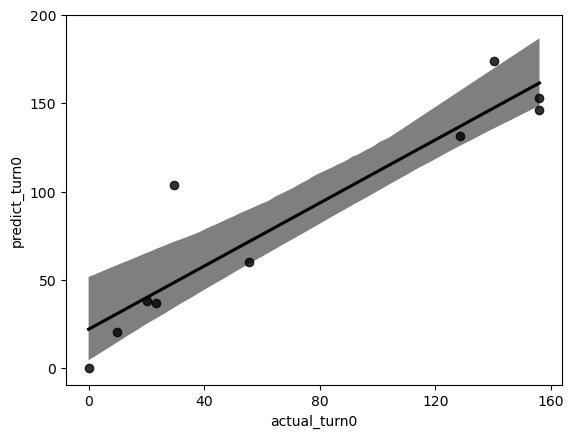

In [3]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Wed Apr  2 14:19:03 2025

@author: hsinyihung
"""


import os, glob
import imageio

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.style.use('default')
file_name = 'singal_data.csv'
directory = 'processed/'
fname = directory+file_name

df_control = pd.read_csv(fname)

x=df_control['actual_turn0']

y = df_control['predict_turn0']

# Calculate the linear regression

slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

sns.regplot(data=df_control, x="actual_turn0", y="predict_turn0" ,   line_kws={"color": "black"},
    scatter_kws={"color": "black"})
plt.xticks([0, 40, 80, 120, 160])
plt.yticks([0, 50, 100, 150, 200])
plt.show()